In [1]:
# my-rdkit-env


import numpy as np
import pandas as pd

from MOLstandardizer import MOLstandardizer

from rdkit import Chem

# METLIN-CCS

## Obtain datasets of uniques

Processing of SMILES to obtain standard absolute SMILES of all unique chemicals in METLIN-CCS

In [2]:
metlinccs = pd.read_csv(r'CCS-Publication-V3\METLIN_IMS_all plot CV %3C2% _dimers_rmTM .csv')

In [3]:
metlinccs.head()

,Molecule Name,Molecular Formula,METLIN ID,Precursor Adduct,CCS1,CCS2,CCS3,CCS_AVG,% CV,m/z,...,m/z.1,Dimer,Dimer.1,dimer line,CCS,m/z.2,pubChem,inchi,smiles,InChIKEY
0,"({[(2,4,6-trimethylphenyl)carbamoyl]methyl}car...",C25H37N3O5,1133361.0,460.2806[M+H],214.67,214.67,214.29,214.54,0.102262,460.2806,...,460.2806,245.447538,Monomer,NaN,135.0,50.0,16384698,InChI=1S/C25H37N3O5/c1-16-11-17(2)22(18(3)12-1...,O=C(COC(=O)C1(CCCC1)CC(=O)NC(C)(C)C)NCC(=O)Nc1...,FEGOCYXICMRAQQ-UHFFFAOYSA-N
1,({[(2-chlorophenyl)carbamoyl]methyl}(methyl)ca...,C24H21ClN2O5,1206876.0,453.1212[M+H],222.35,223.11,222.54,222.67,0.177625,453.1212,...,453.1212,243.520227,Monomer,NaN,310.0,700.0,16292254,InChI=1S/C24H21ClN2O5/c1-27(14-22(29)26-21-5-3...,O=C(Nc1ccccc1Cl)CN(C(=O)COC(=O)c1ccc(cc1)c1ccc...,XZVSMEAQRVNQGK-UHFFFAOYSA-N
2,({[(4-fluorophenyl)carbamoyl]methyl}(methyl)ca...,C21H23F2N3O7S,1210764.0,500.1298[M+H],216.50,214.99,218.20,216.56,0.741567,500.1298,...,500.1298,256.174942,Monomer,NaN,NaN,NaN,17549454,"InChI=1S/C21H23F2N3O7S/c1-13(27)20(25-34(31,32...",Fc1ccc(cc1)NC(=O)CN(C(=O)COC(=O)C(C(O)C)NS(=O)...,LDAYEKIUEBGJLJ-UHFFFAOYSA-N
3,"({[1,1'-biphenyl]-2-yl}carbamoyl)methyl (2S)-1...",C25H23FN2O5S,1202850.0,483.1384[M+H],206.87,206.49,207.25,206.87,0.183690,483.1384,...,483.1384,251.600857,Monomer,NaN,NaN,NaN,16245181,InChI=1S/C25H23FN2O5S/c26-20-12-5-7-15-23(20)3...,O=C(Nc1ccccc1c1ccccc1)COC(=O)[C@@H]1CCCN1S(=O)...,SYBNNAWFJKVTPH-QFIPXVFZSA-N
4,"({[1,1'-biphenyl]-2-yl}carbamoyl)methyl 1,3-th...",C18H14N2O3S,1188636.0,339.0798[M+H],180.55,177.23,180.55,179.44,1.068214,339.0798,...,339.0798,212.820282,Monomer,NaN,NaN,NaN,47085016,InChI=1S/C18H14N2O3S/c21-17(10-23-18(22)16-11-...,O=C(Nc1ccccc1c1ccccc1)COC(=O)c1cscn1,DEQRRNRMXUSVMN-UHFFFAOYSA-N


In [5]:
metlinccs.tail(10)

,Molecule Name,Molecular Formula,METLIN ID,Precursor Adduct,CCS1,CCS2,CCS3,CCS_AVG,% CV,m/z,...,m/z.1,Dimer,Dimer.1,dimer line,CCS,m/z.2,pubChem,inchi,smiles,InChIKEY
61858,"tert-butyl N-{2-[(3,4-dihydro-2H-1-benzopyran-...",C17H24N2O4,1132099.0,343.1628[M+Na],257.76,257.76,258.13,257.88,0.082837,343.1628,...,343.1628,213.919426,Dimer,NaN,NaN,NaN,45848238,"InChI=1S/C17H24N2O4/c1-17(2,3)23-16(21)18-10-8...",O=C(NC1CCOc2c1cccc2)CCNC(=O)OC(C)(C)C,JDNWPQCMAGAFDO-UHFFFAOYSA-N
61859,tert-butyl({2-hydroxy-3-[(2-methoxyphenyl)meth...,C15H25NO3,1170904.0,290.1727[M+Na],170.83,168.46,170.04,169.78,0.710770,290.1727,...,290.1727,199.654491,Monomer,NaN,NaN,NaN,5149382,"InChI=1S/C15H25NO3/c1-15(2,3)16-9-13(17)11-19-...",COc1ccccc1COCC(CNC(C)(C)C)O,JZKDASLHLVIEAD-UHFFFAOYSA-N
61860,Trapidil,C10H15N5,988017.0,228.1220[M+Na],157.62,160.43,159.23,159.09,0.886276,228.1220,...,228.1220,182.950442,Monomer,NaN,NaN,NaN,5531,InChI=1S/C10H15N5/c1-4-14(5-2)9-6-8(3)13-10-11...,CCN(c1cc(C)nc2n1ncn2)CC,GSNOZLZNQMLSKJ-UHFFFAOYSA-N
61861,tyloxapol,C21H20N2O4,1107307.0,387.1315[M+Na],185.31,184.93,184.54,184.93,0.208193,387.1315,...,387.1315,225.755800,Monomer,NaN,NaN,NaN,NaN,InChI=1S/C21H20N2O4/c1-23(20(24)15-27-16-8-3-2...,O=C(N(c1ccccc1C(=O)NCc1ccco1)C)COc1ccccc1,SGSZAVKEVSVBPS-UHFFFAOYSA-N
61862,Veratric acid,C9H10O4,1079.0,205.0471[M+Na],204.53,202.55,203.34,203.47,0.489857,205.0471,...,205.0471,176.738679,Dimer,NaN,NaN,NaN,7121,InChI=1/C9H10O4/c1-12-7-4-3-6(9(10)11)5-8(7)13...,COc1ccc(cc1OC)C(=O)O,DAUAQNGYDSHRET-UHFFFAOYSA-N
61863,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,--,--,--,DAUAQNGYDSHRET-UHFFFAOYSA-N
61864,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3822,NaN,NaN,NaN,--,--,--,DAUAQNGYDSHRET-UHFFFAOYSA-N
61865,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,58040,NaN,NaN,NaN,--,--,--,DAUAQNGYDSHRET-UHFFFAOYSA-N
61866,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,--,--,--,DAUAQNGYDSHRET-UHFFFAOYSA-N
61867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,61862,NaN,NaN,NaN,--,--,--,DAUAQNGYDSHRET-UHFFFAOYSA-N


In [10]:
metlinccs['% CV'].mean(), metlinccs['% CV'].median(), np.nanpercentile(metlinccs['% CV'], 95)

(np.float64(0.36097957255994706),
 np.float64(0.28385682),
 np.float64(0.9737088690999988))

drop dimers

In [126]:
metlinccs['Dimer.1'].isna().sum()

np.int64(0)

In [3]:
metlinccs.query('`Dimer.1` == "Monomer"', inplace = True)

In [6]:
metlinccs.InChIKEY.isna().sum(), metlinccs.smiles.isna().sum(), metlinccs.inchi.isna().sum()

(np.int64(0), np.int64(0), np.int64(0))

checking uniqueness

In [7]:
metlinccs.InChIKEY.unique().size

27377

In [ ]:
# checking stereochemistry uniqueness
metlinccs.InChIKey.unique().size, metlinccs.InChIKey.str[:14].unique().size

(27377, 27377)

selecting uniques

In [4]:
nonstandard_unique_inchikeys_idx = metlinccs.InChIKEY.drop_duplicates().index

In [5]:
nonstandard_unique_smiles = metlinccs.smiles[nonstandard_unique_inchikeys_idx]

perform standardization

In [8]:
standardized_info = [] # list to save molecular info dictionaries
def standardizer(smiles_string):
    try:
        return MOLstandardizer(
            input=smiles_string, input_type='SMILES', 
            stereochemistry=True, smiles=True, inchikey=True, molecular_formula=True, monoisotopic_mass=True
        )
    except Exception:
        return None
standardized_info = [standardizer(s) for s in nonstandard_unique_smiles]

dealing with Nones

In [10]:
nones = [element is None for element in standardized_info]

In [ ]:
sum(nones)

3

In [ ]:
none_smiles = nonstandard_unique_smiles[nones]
none_stds = np.arange(len(standardized_info))[nones]
for i in range(len(none_smiles)): # try with InChI
    standardized_info[none_stds[i]] = MOLstandardizer(input=metlinccs.at[none_smiles.index[i], 'inchi'],
                                                      input_type='InChI', 
                                                      smiles=True, inchikey=True, 
                                                      molecular_formula=True, monoisotopic_mass=True)

In [ ]:
sum([element is None for element in standardized_info])

0

saving information

In [ ]:
standardized_info = pd.DataFrame(standardized_info)

In [ ]:
results = pd.concat([pd.Series(nonstandard_unique_inchikeys_idx, name = 'METLIN_IDX'), 
                     standardized_info['Absolute SMILES'],
                     standardized_info['InChIKey'],
                     standardized_info['Molecular Formula'],
                     standardized_info['Monoisotopic Mass']], axis=1)

In [22]:
results.shape

(27377, 5)

In [13]:
# checking stereochemistry uniqueness
results.InChIKey.unique().size, results.InChIKey.str[:14].unique().size

(27377, 27377)

In [ ]:
results.to_csv('METLINuniques.csv', index = False)

saving MOLs

In [ ]:
writer = Chem.SDWriter('METLINuniques.sdf')
for i, mol in enumerate(standardized_info['MOL']):
    mol.SetProp('METLIN_IDX', str(nonstandard_unique_inchikeys_idx[i]))
    mol.SetProp('SMILES', results.loc[i, 'Absolute SMILES'])
    mol.SetProp('InChIKey', results.loc[i, 'InChIKey'])
    writer.write(mol)
writer.close()

checking SMILES reconstruction from SDF file

In [ ]:
sdf_supplier = Chem.SDMolSupplier('METLINuniques.sdf')
mols_from_sdf = [mol for mol in sdf_supplier]

smiles_from_sdf = pd.Series([Chem.MolToSmiles(mol) for mol in mols_from_sdf])

equality_check = smiles_from_sdf == standardized_info['Absolute SMILES']
print("Matching SMILES:", equality_check.sum(), "out of", len(standardized_info['Absolute SMILES']))

Matching SMILES: 27377 out of 27377

## Cleaning and preparing METLIN-*CCS*

In [2]:
metlinccs = pd.read_csv(r'CCS-Publication-V3\METLIN_IMS_all plot CV %3C2% _dimers_rmTM .csv')

In [3]:
metlinccs.query('`Dimer.1` == "Monomer"', inplace = True)

In [4]:
metlinccs.drop(columns=['Molecular Formula', 'METLIN ID', 'Precursor Adduct', 
                        'CCS1', 'CCS2', 'CCS3', 'm/z.1', 
                        'Dimer', 'Dimer.1', 'dimer line', 'CCS', 'm/z.2', 'pubChem',
                        'smiles', 'inchi', 'Molecule Name'], inplace=True)

In [165]:
metlinccs

,CCS_AVG,% CV,m/z,Adduct,InChIKEY
0,214.54,0.102262,460.2806,[M+H],FEGOCYXICMRAQQ-UHFFFAOYSA-N
1,222.67,0.177625,453.1212,[M+H],XZVSMEAQRVNQGK-UHFFFAOYSA-N
2,216.56,0.741567,500.1298,[M+H],LDAYEKIUEBGJLJ-UHFFFAOYSA-N
3,206.87,0.183690,483.1384,[M+H],SYBNNAWFJKVTPH-QFIPXVFZSA-N
4,179.44,1.068214,339.0798,[M+H],DEQRRNRMXUSVMN-UHFFFAOYSA-N
...,...,...,...,...,...
61856,204.37,0.626487,355.1992,[M+Na],RSTARVCDDQJIDX-UHFFFAOYSA-N
61857,204.05,0.286614,454.1504,[M+Na],ZADSSDKUYJNFJQ-UHFFFAOYSA-N
61859,169.78,0.710770,290.1727,[M+Na],JZKDASLHLVIEAD-UHFFFAOYSA-N
61860,159.09,0.886276,228.1220,[M+Na],GSNOZLZNQMLSKJ-UHFFFAOYSA-N


let's add the standardized identifiers

In [5]:
standardized_id = pd.read_csv('METLINuniques.csv')
standardized_id.head()

,METLIN_IDX,Absolute SMILES,InChIKey,Molecular Formula,Monoisotopic Mass
0,0,Cc1cc(C)c(NC(=O)CNC(=O)COC(=O)C2(CC(=O)NC(C)(C...,FEGOCYXICMRAQQ-UHFFFAOYSA-N,C25H37N3O5,459.273321
1,1,CN(CC(=O)Nc1ccccc1Cl)C(=O)COC(=O)c1ccc(-c2ccc(...,XZVSMEAQRVNQGK-UHFFFAOYSA-N,C24H21ClN2O5,452.113899
2,2,CC(O)C(NS(=O)(=O)c1ccc(F)cc1)C(=O)OCC(=O)N(C)C...,LDAYEKIUEBGJLJ-UHFFFAOYSA-N,C21H23F2N3O7S,499.122478
3,3,O=C(COC(=O)C1CCCN1S(=O)(=O)c1ccccc1F)Nc1ccccc1...,SYBNNAWFJKVTPH-UHFFFAOYSA-N,C25H23FN2O5S,482.131171
4,4,O=C(COC(=O)c1cscn1)Nc1ccccc1-c1ccccc1,DEQRRNRMXUSVMN-UHFFFAOYSA-N,C18H14N2O3S,338.072513


In [6]:
metlinccs['Absolute SMILES'] = 'No unique info'
metlinccs['InChIKey'] = 'No unique info'
metlinccs['Molecular Formula'] = 'No unique info'
metlinccs['Monoisotopic Mass'] = 'No unique info'

for idx, unique in standardized_id.iterrows():
    mask = metlinccs.InChIKEY == metlinccs.at[unique.METLIN_IDX, 'InChIKEY']
    if sum(~metlinccs.loc[mask, 'InChIKey'].isin(['No unique info'])) > 0:
        print('Ups, something went wrong.')
        break
    metlinccs.loc[mask, 'Absolute SMILES'] = unique['Absolute SMILES']
    metlinccs.loc[mask, 'InChIKey'] = unique.InChIKey
    metlinccs.loc[mask, 'Molecular Formula'] = unique['Molecular Formula']
    metlinccs.loc[mask, 'Monoisotopic Mass'] = unique['Monoisotopic Mass']

In [7]:
((metlinccs['Absolute SMILES'] == 'No unique info').sum(), (metlinccs['InChIKey'] == 'No unique info').sum(),
(metlinccs['Molecular Formula'] == 'No unique info').sum(), (metlinccs['Monoisotopic Mass'] == 'No unique info').sum())

(np.int64(0), np.int64(0), np.int64(0), np.int64(0))

In [8]:
len(metlinccs['Absolute SMILES'].unique()), len(metlinccs.InChIKey.unique())

(27377, 27377)

calculate m/z values from monoisotopic mass

In [ ]:
ADDUCT_MASSES = { # https://www.ciaaw.org/index.htm
    '[M+H]': 1.0078250322,
    '[M+Na]': 22.98976928,
    '[M-H]': -1.0078250322,
}

theoretical = metlinccs['Monoisotopic Mass'] + metlinccs['Adduct'].map(ADDUCT_MASSES)
error = theoretical * 1e-5 # TOF
lower = theoretical - error
upper = theoretical + error
mask = (metlinccs['m/z'] <= upper) & (metlinccs['m/z'] >= lower)

In [10]:
metlinccs.loc[~mask]

,CCS_AVG,% CV,m/z,Adduct,InChIKEY,Absolute SMILES,InChIKey,Molecular Formula,Monoisotopic Mass
4737,213.47,1.402359,426.3003,[M+H],FOPZZBALPAFKPO-UHFFFAOYSA-N,O=C(O)COc1ccc(C23CC4CC(CC(C4)C2)C3)cc1,WIWCHWGNONICJI-UHFFFAOYSA-N,C18H22O3,286.156895
25496,182.54,0.213652,318.0907,[M+H],CEBFCODTYYCQPK-UHFFFAOYSA-N,CCN(c1ccccc1)S(=O)(=O)c1ccc2c(c1)=NC(=O)N=2,BZBXQMLAGLVOSG-UHFFFAOYSA-N,C15H13N3O3S,315.067762
35308,183.22,1.641776,300.1592,[M-H],YVUXAKLXTSKVQI-UHFFFAOYSA-N,CC(C)Cn1cnc2c1c(=O)[nH]c(=O)n2Cc1ccccc1,YVUXAKLXTSKVQI-UHFFFAOYSA-N,C16H18N4O2,298.142976
35309,189.25,0.533877,314.1748,[M-H],WWLSWWUWCXHXTL-UHFFFAOYSA-M,CC(C)CCn1cnc2c1c(=O)[nH]c(=O)n2Cc1ccccc1,CEQIAZJXNKAVAP-UHFFFAOYSA-N,C17H20N4O2,312.158626
35312,180.42,0.273467,300.1592,[M-H],BVJSZBTUHSBXOM-UHFFFAOYSA-N,CCCCn1cnc2c1c(=O)[nH]c(=O)n2Cc1ccccc1,BVJSZBTUHSBXOM-UHFFFAOYSA-N,C16H18N4O2,298.142976
36007,164.08,1.295111,299.1224,[M-H],ZKDIYAHSBCSVQB-UHFFFAOYSA-N,Cc1ccccc1C=c1sc2nc3ccccc3n2c1=O,KLZMNEYZVKWNME-UHFFFAOYSA-N,C17H12N2OS,292.067034
44136,170.38,0.064383,316.0761,[M-H],CEBFCODTYYCQPK-UHFFFAOYSA-N,CCN(c1ccccc1)S(=O)(=O)c1ccc2c(c1)=NC(=O)N=2,BZBXQMLAGLVOSG-UHFFFAOYSA-N,C15H13N3O3S,315.067762
61564,188.93,0.329314,340.0726,[M+Na],CEBFCODTYYCQPK-UHFFFAOYSA-N,CCN(c1ccccc1)S(=O)(=O)c1ccc2c(c1)=NC(=O)N=2,BZBXQMLAGLVOSG-UHFFFAOYSA-N,C15H13N3O3S,315.067762


I have decided to leave these in because this was not in the usual data preprocessing of the other papers, but should be removed in further projects!!!

format adduct species and column names

In [ ]:
metlinccs.rename(columns={'CCS_AVG': 'CCS'}, inplace=True)
metlinccs.index.name = 'METLIN_IDX'
metlinccs = metlinccs.reindex(columns=['Absolute SMILES', 'InChIKey', 'Molecular Formula', 
                                       'Monoisotopic Mass', 'Adduct', 'm/z', 'CCS', '% CV'])

In [ ]:
ADDUCT_FORMATS = {
    '[M+H]': '[M+H]+',
    '[M+Na]': '[M+Na]+',
    '[M-H]': '[M-H]-',
}

for adduct_old, adduct_new in ADDUCT_FORMATS.items():
    mask = metlinccs["Adduct"] == adduct_old
    metlinccs.loc[mask, "Adduct"] = adduct_new

checking duplicated entries

In [ ]:
grouped = metlinccs.groupby(by = ['InChIKey', 'Adduct'])
for name, group in grouped:
    if len(group) > 1:
        print(group)

In [185]:
# METLIN_IDX also saved as first column
metlinccs.to_csv('METLINclean.csv')

In [1]:
import pandas as pd
from sklearn.metrics import r2_score

In [2]:
metlinccs = pd.read_csv('METLINclean.csv')

In [3]:
# Keep only the two adducts of interest
df_sub = metlinccs[metlinccs["Adduct"].isin(["[M-H]-", "[M+Na]+"])]

# Pivot so each InChIKey has one row
pivot = (
    df_sub.pivot_table(
        index="InChIKey",
        columns="Adduct",
        values="CCS",
        aggfunc="first"   # use mean if duplicates should be averaged
    )
)

# Keep only compounds with both adducts
paired = pivot.dropna()

print(f"Number of paired compounds: {len(paired)}")

# Calculate R²
r2 = r2_score(
    paired["[M-H]-"],
    paired["[M+Na]+"]
)

print("R² =", r2)

Number of paired compounds: 10311
R² = 0.5967171455412792


## Generate splits

In [1]:
# base


import numpy as np
import pandas as pd

from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import pickle as pkl
import h5py
from tqdm import tqdm

In [2]:
sns.set_theme(
        style='white',
        font="Arial",
        rc={
            "text.color": "black",
            "axes.labelcolor": "black",
            "xtick.color": "black",
            "ytick.color": "black",
            "axes.labelsize": 10,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "legend.fontsize": 10,
            "axes.linewidth": 1,
            "xtick.major.width": 1,
            "ytick.major.width": 1,
            "xtick.minor.width": 1,
            "ytick.minor.width": 1,
        }
)

palette = ["#6C8EBF", "#AE6666", "#cdb571", "#780000","#B5C6DF","#EADAAA",] # sns.color_palette('deep')

### final

In [3]:
X = pd.read_csv('METLINclean.csv')
Xuniques = pd.read_csv('METLINuniques.csv')

with h5py.File('MCES/results10.h5', 'r') as f:
    first_idxs = f['first_idx'][:] # idx of first molecule in the MCES pair
    second_idxs = f['second_idx'][:] # idx of second molecule in the MCES pair
    dists = f['distance'][:].astype(np.float32) # myopic MCES distances

In [3]:
train_idxs, cal_idxs = train_test_split(np.arange(X.shape[0]), test_size=1/10, random_state=42)

In [7]:
targets = (X.loc[train_idxs, 'CCS'].to_numpy(), X.loc[cal_idxs, 'CCS'].to_numpy())

In [8]:
# since MCES results are stored with indexes of the unique compounds,
# transform full database indexes to unique compounds indexes
uniques_idxs = np.arange(Xuniques.shape[0])
mces_train_idxs = uniques_idxs[Xuniques['InChIKey'].isin(X.loc[train_idxs, 'InChIKey'].unique())]
mces_cal_idxs = uniques_idxs[Xuniques['InChIKey'].isin(X.loc[cal_idxs, 'InChIKey'].unique())]

In [9]:
split_dists = (
    dists[np.isin(first_idxs, mces_train_idxs) & np.isin(second_idxs, mces_train_idxs)], 
    dists[np.isin(first_idxs, mces_cal_idxs) & np.isin(second_idxs, mces_cal_idxs)]
)

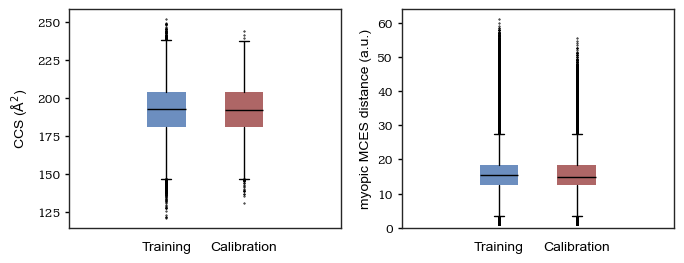

In [10]:
fig, ((ax0, ax1)) = plt.subplots(
        ncols=2,
        figsize=(7, 2.8),
    )

bp1 = ax0.boxplot([targets[0], targets[1]], sym='.', tick_labels=['Training', 'Calibration'], flierprops=dict(color='black', markersize=1), widths=0.2, patch_artist=True,
            boxprops=dict(linewidth=0), whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1), capwidths=0.05, medianprops = dict(color='black'), positions=[0, 0.4])
for i, box in enumerate(bp1['boxes']):
    box.set_facecolor(palette[i])
    #box.set_alpha(0.69)
ax0.set_ylabel(r'CCS ($\mathrm{\AA}^2$)')
ax0.tick_params(left=True, labelfontfamily='kameron', labelsize=10, axis='y', length=3)
ax0.tick_params(axis='x', labelbottom=True, bottom = False)
#ax0.legend(labels = ['Training', 'Calibration'], loc='lower left', frameon=False, handlelength = 0.5, handletextpad = 0.4, borderaxespad=0)
# ax0.grid(
#     axis='y',
#     which='major',
#     linestyle='-',
#     linewidth=1,
#     alpha=0.1,
#     color = 'black'
# )

bp2 = ax1.boxplot([split_dists[0], split_dists[1]], sym='.', tick_labels=['Training', 'Calibration'], flierprops=dict(color='black', markersize=1), widths=0.2, patch_artist = True,
            boxprops=dict(linewidth=0), whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1), capwidths=0.05, medianprops = dict(color='black'), positions=[0, 0.4])
for i, box in enumerate(bp2['boxes']):
    box.set_facecolor(palette[i])
    #box.set_alpha(0.69)
ax1.set_ylabel(r'myopic MCES distance (a.u.)')
ax1.tick_params(left=True, labelfontfamily='kameron', labelsize=10, axis='y', length=3)
ax1.tick_params(axis='x', labelbottom=True, bottom = False)
ax1.set_ylim(0)
#ax1.legend(labels = ['Training', 'Calibration'], loc='lower left', frameon=False, handlelength = 0.5, handletextpad = 0.4, borderaxespad=0)
# ax1.grid(
#     axis='y',
#     which='major',
#     linestyle='-',
#     linewidth=1,
#     alpha=0.1,
#     color = 'black'
# )

fig.tight_layout()
plt.savefig(
    "manuscript/final_split.png", format='png',
    bbox_inches="tight",
    pad_inches=0.01, 
    dpi=300
)
plt.show()

In [ ]:
with open('final_fold.pkl', 'wb') as f:
    pkl.dump((train_idxs, cal_idxs), f) # absolute indexes, no METLIN IDXS!!!

with open('final_fold_copy.pkl', 'wb') as f:
    pkl.dump((train_idxs, cal_idxs), f)

### 5x5 cross validation

In [11]:
with open('final_fold.pkl', 'rb') as f:
    final_fold = pkl.load(f)

X = pd.read_csv('METLINclean.csv')
Xuniques = pd.read_csv('METLINuniques.csv')

with h5py.File('MCES/results10.h5', 'r') as f:
    first_idxs = f['first_idx'][:] # idx of first molecule in the MCES pair
    second_idxs = f['second_idx'][:] # idx of second molecule in the MCES pair
    dists = f['distance'][:].astype(np.float32) # myopic MCES distances

In [ ]:
final_train_idxs = final_fold[0]
rkf = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = 42)
fold_idxs = {}
sq = np.random.SeedSequence()
print(f'Seed sequence entropy: {sq.entropy}') # use in case to reproduce
seeds = sq.generate_state(25) # random seeds
for i, (rel_train_cal_idxs, rel_val_idxs) in enumerate(rkf.split(final_train_idxs)): # relative splitting!
    rel_train_idxs, rel_cal_idxs = train_test_split(rel_train_cal_idxs, test_size=1/10, random_state=seeds[i])
    fold_idxs[i] = (final_train_idxs[rel_train_idxs], final_train_idxs[rel_cal_idxs], final_train_idxs[rel_val_idxs], seeds[i])

Seed sequence entropy: 112288156909770770843615169223336358937


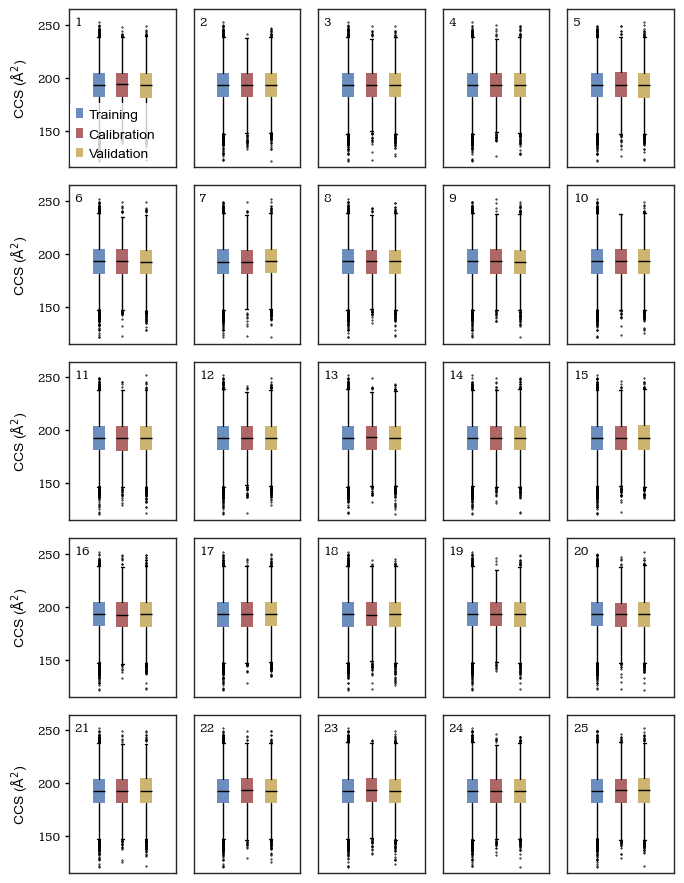

In [14]:
fig, axes = plt.subplots(
        ncols=5, nrows=5,
        figsize=(7, 9),
    )
axes = axes.ravel()

ccs_min, ccs_max = min(X.CCS) - min(X.CCS)*0.05, max(X.CCS) + max(X.CCS)*0.05

for i, ax in enumerate(axes):

    train_idxs, cal_idxs, val_idxs, _ = fold_idxs[i]
    bp = ax.boxplot(
        [X.loc[train_idxs, 'CCS'].to_numpy(), X.loc[cal_idxs, 'CCS'].to_numpy(), X.loc[val_idxs, 'CCS'].to_numpy()],
        sym='.', tick_labels=['Training', 'Calibration', 'Validation'], flierprops=dict(color='black', markersize=1), widths=0.2, patch_artist=True,
        boxprops=dict(linewidth=0), whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1), capwidths=0.05, medianprops = dict(color='black'), positions=[0, 0.4, 0.8]
    )
    for box_idx, box in enumerate(bp['boxes']):
        box.set_facecolor(palette[box_idx])
        #box.set_alpha(0.69)
    ax.text(0.05, 0.95,
        f"{i+1}", transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        fontfamily='Kameron'
    )
    ax.set_ylim(ccs_min, ccs_max)
    ax.tick_params(axis='x', labelbottom=False)

    if i %5 == 0:
        ax.set_ylabel(r'CCS ($\mathrm{\AA}^2$)')
        ax.tick_params(left=True, labelfontfamily='kameron', labelsize=10, axis='y', length=3)
    else:
        ax.tick_params(axis='y', labelleft=False)
    
    if i == 0:
        ax.legend(labels = ['Training', 'Calibration', 'Validation'], loc='lower left', 
                  frameon=True, handlelength = 0.5, handletextpad = 0.4, borderaxespad=0.1, edgecolor='none')
    # ax.grid(
    #     axis='y',
    #     which='major',
    #     linestyle='-',
    #     linewidth=1,
    #     alpha=0.1,
    #     color = 'black'
    # )


fig.tight_layout()
plt.savefig(
    "manuscript/CVsplitsCCS.png", format='png',
    bbox_inches="tight",
    pad_inches=0.01, dpi=300
)
plt.show()

In [13]:
# since MCES results are stored with indexes of the unique compounds,
# transform full database indexes to unique compounds indexes for each fold
uniques_idxs = np.arange(Xuniques.shape[0])
fold_mces_idxs = {}
for fold_idx in range(25):
    mces_train_idxs = uniques_idxs[Xuniques['InChIKey'].isin(X.loc[fold_idxs[fold_idx][0], 'InChIKey'].unique())] # train
    mces_cal_idxs = uniques_idxs[Xuniques['InChIKey'].isin(X.loc[fold_idxs[fold_idx][1], 'InChIKey'].unique())] # cal
    mces_val_idxs = uniques_idxs[Xuniques['InChIKey'].isin(X.loc[fold_idxs[fold_idx][2], 'InChIKey'].unique())] # val
    fold_mces_idxs[fold_idx] = (mces_train_idxs, mces_cal_idxs, mces_val_idxs)

25it [09:20, 22.43s/it]


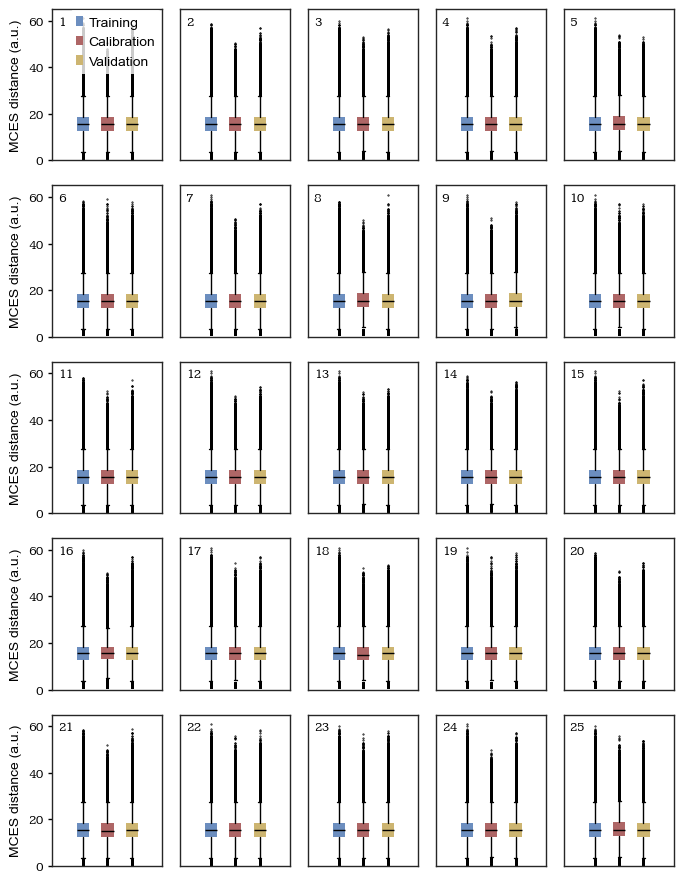

In [14]:
fig, axes = plt.subplots(
        ncols=5, nrows=5,
        figsize=(7, 9),
    )
axes = axes.ravel()

mces_max = max(dists) + 2

for i, ax in tqdm(enumerate(axes)):

    train_idxs, cal_idxs, val_idxs = fold_mces_idxs[i]
    bp = ax.boxplot(
        [
            dists[np.isin(first_idxs, train_idxs) & np.isin(second_idxs, train_idxs)], 
            dists[np.isin(first_idxs, cal_idxs) & np.isin(second_idxs, cal_idxs)], 
            dists[np.isin(first_idxs, val_idxs) & np.isin(second_idxs, val_idxs)]
        ],
        sym='.', tick_labels=['Training', 'Calibration', 'Validation'], flierprops=dict(color='black', markersize=1), widths=0.2, patch_artist=True,
        boxprops=dict(linewidth=0), whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1), capwidths=0.05, medianprops = dict(color='black'), positions=[0, 0.4, 0.8]
    )
    for box_idx, box in enumerate(bp['boxes']):
        box.set_facecolor(palette[box_idx])
        # box.set_alpha(0.69)
    ax.text(0.05, 0.95,
        f"{i+1}", transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        fontfamily='Kameron'
    )
    ax.set_ylim(0, mces_max)
    ax.tick_params(axis='x', labelbottom=False)

    if i %5 == 0:
        ax.set_ylabel(r'MCES distance (a.u.)')
        ax.tick_params(left=True, labelfontfamily='kameron', labelsize=10, axis='y', length=3)
    else:
        ax.tick_params(axis='y', labelleft=False)
    
    if i == 0:
        ax.legend(labels = ['Training', 'Calibration', 'Validation'], loc='upper right',
                  frameon=True, handlelength = 0.5, handletextpad = 0.4, borderaxespad=0.1, edgecolor='none')
    # ax.grid(
    #     axis='y',
    #     which='major',
    #     linestyle='-',
    #     linewidth=1,
    #     alpha=0.1,
    #     color = 'black'
    # )


fig.tight_layout()
plt.savefig(
    "manuscript/CVsplitsMCES.png", format='png',
    bbox_inches="tight",
    pad_inches=0.01, dpi=300
)
plt.show()

In [ ]:
# absolute indexes, no METLIN IDXS!!!
with open('CVfolds.pkl', 'wb') as f:
    pkl.dump(fold_idxs, f)
with open('CVfolds_copy.pkl', 'wb') as f:
    pkl.dump(fold_idxs, f)

## Subsample training data

Sample training data to decrease the number of myopic MCES distance calculations.

In [15]:
sns.set_theme(
        style='white',
        font="Arial",
        rc={
            "text.color": "black",
            "axes.labelcolor": "black",
            "xtick.color": "black",
            "ytick.color": "black",
            "axes.labelsize": 10,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "legend.fontsize": 10,
            "axes.linewidth": 1,
            "xtick.major.width": 1,
            "ytick.major.width": 1,
            "xtick.minor.width": 1,
            "ytick.minor.width": 1,
        }
)

palette = ["#6C8EBF", "#AE6666", "#cdb571", "#780000","#B5C6DF","#EADAAA",] # sns.color_palette('deep')

In [2]:
X = pd.read_csv('METLINclean.csv')
Xuniques = pd.read_csv('METLINuniques.csv')

with h5py.File('MCES/results10.h5', 'r') as f:
    first_idxs = f['first_idx'][:] # idx of first molecule in the MCES pair
    second_idxs = f['second_idx'][:] # idx of second molecule in the MCES pair
    dists = f['distance'][:].astype(np.float32) # myopic MCES distances

Final

In [3]:
with open('final_fold.pkl', 'rb') as f:
    final_fold = pkl.load(f)

In [18]:
# since MCES results are stored with indexes of the unique compounds,
# transform full database indexes to unique compounds indexes
uniques_idxs = np.arange(Xuniques.shape[0], dtype=int)
training_mces = uniques_idxs[Xuniques['InChIKey'].isin(X.loc[final_fold[0], 'InChIKey'].unique())]

In [ ]:
_, training_sample = train_test_split(training_mces, test_size=1/4, random_state=42)

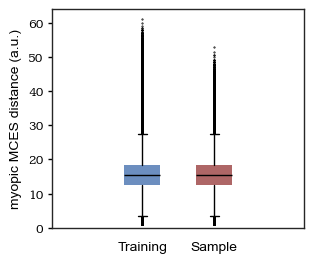

In [20]:
fig, ax = plt.subplots(
        figsize=(3.3, 2.8),
    )

bp1 = ax.boxplot([
        dists[np.isin(first_idxs, training_mces) & np.isin(second_idxs, training_mces)],
        dists[np.isin(first_idxs, training_sample) & np.isin(second_idxs, training_sample)],
    ], sym='.', tick_labels=['Training', 'Sample'], flierprops=dict(color='black', markersize=1), widths=0.2, patch_artist=True,
            boxprops=dict(linewidth=0), whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1), capwidths=0.05, medianprops = dict(color='black'), positions=[0, 0.4])
for i, box in enumerate(bp1['boxes']):
    box.set_facecolor(palette[i])
    # box.set_alpha(0.69)
ax.set_ylabel(r'myopic MCES distance (a.u.)')
ax.tick_params(left=True, labelfontfamily='kameron', labelsize=10, axis='y', length=3)
ax.tick_params(axis='x', labelbottom=True, bottom = False)
# ax.legend(labels = ['Training', 'Sample'], loc='upper right', frameon=False, handlelength = 0.5, handletextpad = 0.4, borderaxespad=0)
# ax.grid(
#     axis='y',
#     which='major',
#     linestyle='-',
#     linewidth=1,
#     alpha=0.1,
#     color = 'black'
# )
ax.set_ylim(0)

fig.tight_layout()
plt.savefig(
    "manuscript/final_split_sub.png", format='png',
    bbox_inches="tight",
    pad_inches=0.01, 
    dpi=300
)
plt.show()

In [21]:
training_sample.size

6668

CV

In [22]:
with open('CVfolds.pkl', 'rb') as f:
    cv_folds = pkl.load(f)

In [23]:
# since MCES results are stored with indexes of the unique compounds,
# transform full database indexes to unique compounds indexes for each fold
fold_mces_train_idxs = [uniques_idxs[Xuniques['InChIKey'].isin(X.loc[cv_folds[fold_idx][0], 'InChIKey'].unique())]
                        for fold_idx in range(25)]

In [24]:
# pre-index training distances per fold
fold_training_distances = [
    dists[np.isin(first_idxs, fold_mces_train_idxs[fold_idx]) & np.isin(second_idxs, fold_mces_train_idxs[fold_idx])]
    for fold_idx in tqdm(range(25))
]

100%|██████████| 25/25 [02:31<00:00,  6.05s/it]


In [ ]:
subsampling_idxs = {}
for i in range(25):
    _, fold_training_sample = train_test_split(fold_mces_train_idxs[i], test_size=1/4, random_state=cv_folds[i][-1])
    subsampling_idxs[i] = fold_training_sample

In [25]:
with open('myopicMCESsubsampleCV.pkl', 'rb') as f:
    subsampling_idxs = pkl.load(f)

25it [06:56, 16.65s/it]


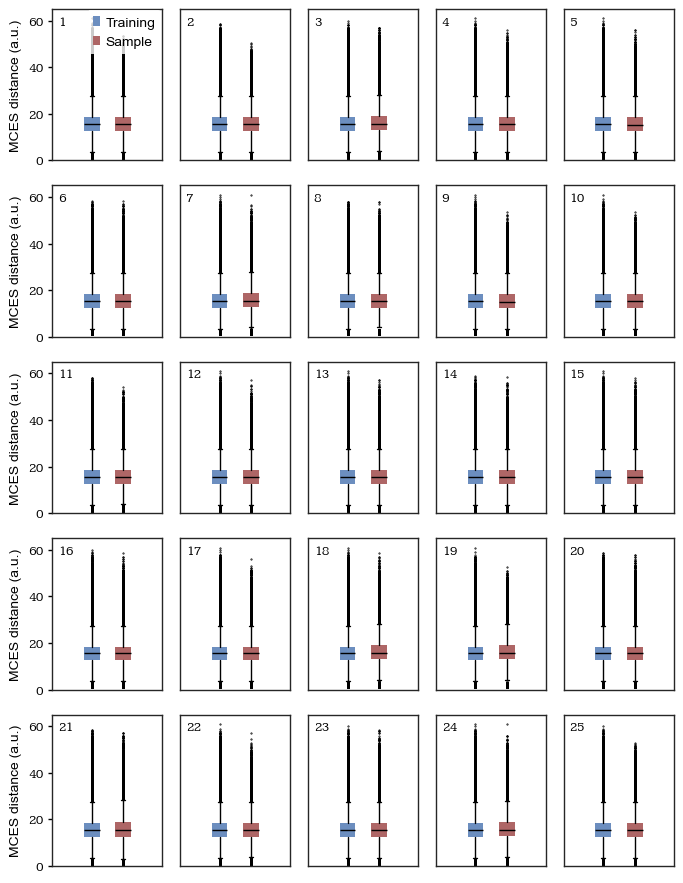

In [26]:
fig, axes = plt.subplots(
        ncols=5, nrows=5,
        figsize=(7, 9),
    )
axes = axes.ravel()

mces_max = max(dists) + 2

for i, ax in tqdm(enumerate(axes)):

    bp = ax.boxplot(
        [
            fold_training_distances[i],
            dists[np.isin(first_idxs, subsampling_idxs[i]) & np.isin(second_idxs, subsampling_idxs[i])],
        ],
        sym='.', tick_labels=['Training', 'Sample'], flierprops=dict(color='black', markersize=1), widths=0.2, patch_artist=True,
        boxprops=dict(linewidth=0), whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1), capwidths=0.05, medianprops = dict(color='black'), positions=[0, 0.4]
    )
    for box_idx, box in enumerate(bp['boxes']):
        box.set_facecolor(palette[box_idx])
        # box.set_alpha(0.69)
    ax.text(0.05, 0.95,
        f"{i+1}", transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        fontfamily='Kameron'
    )
    ax.set_ylim(0, mces_max)
    ax.tick_params(axis='x', labelbottom=False)

    if i %5 == 0:
        ax.set_ylabel(r'MCES distance (a.u.)')
        ax.tick_params(left=True, labelfontfamily='kameron', labelsize=10, axis='y', length=3)
    else:
        ax.tick_params(axis='y', labelleft=False)
    
    if i == 0:
        ax.legend(labels = ['Training', 'Sample'], loc='upper right',
                  frameon=True, handlelength = 0.5, handletextpad = 0.4, borderaxespad=0.1, edgecolor='none')
    # ax.grid(
    #     axis='y',
    #     which='major',
    #     linestyle='-',
    #     linewidth=1,
    #     alpha=0.1,
    #     color = 'black'
    # )


fig.tight_layout()
plt.savefig(
    "manuscript/CVsplitsMCESsub.png", format='png',
    bbox_inches="tight",
    pad_inches=0.01, dpi=300
)
plt.show()

In [ ]:
fold_training_sample.size

5837

In [ ]:
np.save('myopicMCESsubsample_final.npy', training_sample) # idxs of uniques

In [ ]:
# idxs of uniques
with open('myopicMCESsubsampleCV.pkl', 'wb') as f:
    pkl.dump(subsampling_idxs, f)
with open('myopicMCESsubsampleCVcopy.pkl', 'wb') as f:
    pkl.dump(subsampling_idxs, f)

# EnvTox

## Uniques

In [222]:
envtox = pd.read_excel('EnvTox.xlsx', usecols = ['Precursor Adduct', 'Precursor Charge',
                                              'InChI', 'SMILES', 'InChIKey'])

In [223]:
envtox.head()

,Precursor Adduct,Precursor Charge,InChI,SMILES,InChIKey
0,[M+Na],1,InChI=1S/C8H14O6/c1-3-13-7(11)5(9)6(10)8(12)14...,CCOC(=O)[C@@H](O)[C@H](O)C(=O)OCC,YSAVZVORKRDODB-WDSKDSINSA-N
1,[M+Na],1,InChI=1S/C18H18O4/c19-15-5-1-3-12(8-15)7-14-11...,OC1=CC(C[C@H]2COC(=O)[C@@H]2CC2=CC(O)=CC=C2)=C...,HVDGDHBAMCBBLR-WMLDXEAASA-N
2,[M-H],-1,InChI=1S/C18H18O4/c19-15-5-1-3-12(8-15)7-14-11...,OC1=CC(C[C@H]2COC(=O)[C@@H]2CC2=CC(O)=CC=C2)=C...,HVDGDHBAMCBBLR-WMLDXEAASA-N
3,[M+Na],1,InChI=1S/C22H18O11/c23-10-5-12(24)11-7-18(33-2...,OC1=CC(O)=C2C[C@@H](OC(=O)C3=CC(O)=C(O)C(O)=C3...,WMBWREPUVVBILR-WIYYLYMNSA-N
4,[M+H],1,InChI=1S/C10H14N2/c1-12-7-3-5-10(12)9-4-2-6-11...,CN1CCC[C@H]1C1=CN=CC=C1,SNICXCGAKADSCV-JTQLQIEISA-N


In [224]:
envtox.tail()

,Precursor Adduct,Precursor Charge,InChI,SMILES,InChIKey
3916,[M-H],-1,InChI=1S/C17H11BrClFN2O4/c18-10-2-1-9(13(20)5-...,OC(=O)CN1C(=O)N(CC2=CC=C(Br)C=C2F)C(=O)C2=C1C=...,SXONDGSPUVNZLO-UHFFFAOYSA-N
3917,[M+Na],1,InChI=1S/C11H12N2O2S/c1-7(13(15)11(12)14)10-6-...,CC(N(O)C(N)=O)C1=CC2=C(S1)C=CC=C2,MWLSOWXNZPKENC-UHFFFAOYSA-N
3918,[M+Na],1,"InChI=1S/C14H16Cl3NO2/c1-4-14(3,12(19)7-15)18-...",CCC(C)(NC(=O)C1=CC(Cl)=C(C)C(Cl)=C1)C(=O)CCl,SOUGWDPPRBKJEX-UHFFFAOYSA-N
3919,[M+H],1,"InChI=1S/C14H16Cl3NO2/c1-4-14(3,12(19)7-15)18-...",CCC(C)(NC(=O)C1=CC(Cl)=C(C)C(Cl)=C1)C(=O)CCl,SOUGWDPPRBKJEX-UHFFFAOYSA-N
3920,[M+Na],1,"InChI=1S/C10H9Cl4O4P/c1-16-19(15,17-2)18-10(5-...",COP(=O)(OC)O\C(=C/Cl)C1=C(Cl)C=C(Cl)C(Cl)=C1,UBCKGWBNUIFUST-YHYXMXQVSA-N


drop adduct types not included in METLIN-CCS

In [225]:
envtox['Precursor Adduct'].isna().sum()

np.int64(0)

In [226]:
envtox.query('`Precursor Adduct` in ["[M+H]", "[M+Na]", "[M-H]"]', inplace = True)

In [227]:
envtox.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       3911, 3912, 3913, 3914, 3915, 3916, 3917, 3918, 3919, 3920],
      dtype='int64', length=3750)

double check that not any "weird" adducts are present

In [228]:
envtox[(envtox['Precursor Adduct'] == '[M+H]') & (envtox['Precursor Charge'] != 1)].shape

(0, 5)

In [229]:
envtox[(envtox['Precursor Adduct'] == '[M+Na]') & (envtox['Precursor Charge'] != 1)].shape

(0, 5)

In [230]:
envtox[(envtox['Precursor Adduct'] == '[M-H]') & (envtox['Precursor Charge'] != -1)].shape

(2, 5)

In [231]:
envtox[(envtox['Precursor Adduct'] == '[M-H]') & (envtox['Precursor Charge'] != -1)]

,Precursor Adduct,Precursor Charge,InChI,SMILES,InChIKey
1913,[M-H],1,InChI=1S/C12H12N2.2BrH.H2O/c1-3-7-13-9-10-14-8...,O.[Br-].[Br-].C1C[N+]2=C(C=CC=C2)C2=[N+]1C=CC=C2,KLJOSQAQZMLLMB-UHFFFAOYSA-L
1914,[M-H],1,InChI=1S/C12H12N2.2BrH.H2O/c1-3-7-13-9-10-14-8...,O.[Br-].[Br-].C1C[N+]2=C(C=CC=C2)C2=[N+]1C=CC=C2,KLJOSQAQZMLLMB-UHFFFAOYSA-L


In [232]:
envtox.drop(index = [1913, 1914], inplace=True)

In [233]:
envtox.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       3911, 3912, 3913, 3914, 3915, 3916, 3917, 3918, 3919, 3920],
      dtype='int64', length=3748)

In [234]:
envtox[(envtox['Precursor Adduct'] == '[M-H]') & (envtox['Precursor Charge'] != -1)].shape

(0, 5)

In [235]:
envtox.InChI.isna().sum(), envtox.SMILES.isna().sum(), envtox.InChIKey.isna().sum()

(np.int64(0), np.int64(0), np.int64(0))

checking uniques

In [236]:
envtox.InChIKey.unique().size

2023

In [237]:
# checking stereochemistry uniqueness
envtox.InChIKey.unique().size, envtox.InChIKey.str[:14].unique().size

(2023, 2006)

selecting uniques

In [238]:
nonstandard_unique_inchikeys_idx = envtox.InChIKey.drop_duplicates().index

In [239]:
nonstandard_unique_inchikeys_idx

Index([   0,    1,    3,    4,    6,    7,    8,    9,   11,   12,
       ...
       3901, 3904, 3905, 3909, 3912, 3915, 3916, 3917, 3918, 3920],
      dtype='int64', length=2023)

In [240]:
nonstandard_unique_smiles = envtox.SMILES[nonstandard_unique_inchikeys_idx]

perform standardization

In [241]:
standardized_info = [] # list to save molecular info dictionaries
def standardizer(smiles_string):
    return MOLstandardizer(
        input=smiles_string, input_type='SMILES', 
        stereochemistry=True, smiles=True, inchikey=True, molecular_formula=True, monoisotopic_mass=True
    )
standardized_info = [standardizer(s) for s in nonstandard_unique_smiles]

dealing with Nones

In [242]:
nones = [element is None for element in standardized_info]
sum(nones)

0

saving information

In [243]:
standardized_info = pd.DataFrame(standardized_info)

In [244]:
results = pd.concat([pd.Series(nonstandard_unique_inchikeys_idx, name = 'EnvToxIDX'),
                     standardized_info['Absolute SMILES'],
                     standardized_info['InChIKey'],
                     standardized_info['Molecular Formula'],
                     standardized_info['Monoisotopic Mass']], axis=1)

In [245]:
results.shape

(2023, 5)

In [246]:
# checking stereochemistry uniqueness
results.InChIKey.unique().size, results.InChIKey.str[:14].unique().size

(1936, 1927)

In [247]:
results.to_csv('standardizedEnvTox_info.csv', index=False) # careful! there are some repeated chemicals

In [248]:
results.loc[~results.InChIKey.duplicated()].to_csv('EnvTox_uniques.csv', index=False)
# mark all duplicates as True except for the first occurence

saving MOLs

In [249]:
writer = Chem.SDWriter('EnvTox_uniques.sdf')
for i, mol in enumerate(standardized_info['MOL']):
    mol.SetProp('EnvToxIDX', str(nonstandard_unique_inchikeys_idx[i]))
    mol.SetProp('SMILES', results.loc[i, 'Absolute SMILES'])
    mol.SetProp('InChIKey', results.loc[i, 'InChIKey'])
    writer.write(mol)
writer.close()

## Cleaning and preparing EnvTox

In [24]:
envtox = pd.read_excel('EnvTox.xlsx', usecols = ['Precursor Adduct', 'Precursor CCS',
                                              'InChIKey', 'Precursor Mz'])

In [25]:
envtox.rename(columns={'InChIKey': 'InChIKey_old'}, inplace=True) # needed to avoid collapse with standardized InChIKeys

In [26]:
envtox.query('`Precursor Adduct` in ["[M+H]", "[M+Na]", "[M-H]"]', inplace = True)
envtox.drop(index = [1913, 1914], inplace=True) # weird adducts

let's add the standardized identifiers

In [295]:
standardized_id = pd.read_csv('standardizedEnvTox_info.csv')
standardized_id.head()

,EnvToxIDX,Absolute SMILES,InChIKey,Molecular Formula,Monoisotopic Mass
0,0,CCOC(=O)C(O)C(O)C(=O)OCC,YSAVZVORKRDODB-UHFFFAOYSA-N,C8H14O6,206.079038
1,1,O=C1OCC(Cc2cccc(O)c2)C1Cc1cccc(O)c1,HVDGDHBAMCBBLR-UHFFFAOYSA-N,C18H18O4,298.120509
2,3,O=C(O[C@@H]1Cc2c(O)cc(O)cc2O[C@@H]1c1cc(O)c(O)...,WMBWREPUVVBILR-WIYYLYMNSA-N,C22H18O11,458.084911
3,4,CN1CCC[C@H]1c1cccnc1,SNICXCGAKADSCV-JTQLQIEISA-N,C10H14N2,162.115698
4,6,CNC[C@H](O)c1cccc(O)c1,SONNWYBIRXJNDC-VIFPVBQESA-N,C9H13NO2,167.094629


In [27]:
envtox['Absolute SMILES'] = 'No unique info'
envtox['InChIKey'] = 'No unique info'
envtox['Molecular Formula'] = 'No unique info'
envtox['Monoisotopic Mass'] = 'No unique info'

for idx, unique in standardized_id.iterrows():
    mask = envtox.InChIKey_old == envtox.at[unique.EnvToxIDX, 'InChIKey_old']
    if sum(~envtox.loc[mask, 'InChIKey'].isin(['No unique info'])) > 0:
        print('Ups, something went wrong.')
        break
    envtox.loc[mask, 'Absolute SMILES'] = unique['Absolute SMILES']
    envtox.loc[mask, 'InChIKey'] = unique.InChIKey
    envtox.loc[mask, 'Molecular Formula'] = unique['Molecular Formula']
    envtox.loc[mask, 'Monoisotopic Mass'] = unique['Monoisotopic Mass']

In [28]:
((envtox['Absolute SMILES'] == 'No unique info').sum(), (envtox['InChIKey'] == 'No unique info').sum(),
(envtox['Molecular Formula'] == 'No unique info').sum(), (envtox['Monoisotopic Mass'] == 'No unique info').sum())

(np.int64(0), np.int64(0), np.int64(0), np.int64(0))

In [298]:
envtox.columns

Index(['Precursor Adduct', 'Precursor CCS', 'Precursor Mz', 'InChIKey_old',
       'Absolute SMILES', 'InChIKey', 'Molecular Formula',
       'Monoisotopic Mass'],
      dtype='object')

In [8]:
len(envtox['Absolute SMILES'].unique()), len(envtox.InChIKey.unique())

(1936, 1936)

calculate m/z values from monoisotopic mass

In [29]:
ADDUCT_MASSES = { # https://www.ciaaw.org/index.htm
    '[M+H]': 1.0078250322,
    '[M+Na]': 22.98976928,
    '[M-H]': -1.0078250322,
}

theoretical = envtox['Monoisotopic Mass'] + envtox['Precursor Adduct'].map(ADDUCT_MASSES)
error = theoretical * 5 * 1e-5
lower = theoretical - error
upper = theoretical + error
mask = (envtox['Precursor Mz'] <= upper) & (envtox['Precursor Mz'] >= lower)

In [301]:
envtox.loc[~mask]

,Precursor Adduct,Precursor CCS,Precursor Mz,InChIKey_old,Absolute SMILES,InChIKey,Molecular Formula,Monoisotopic Mass
177,[M+H],147.6,220.1119,GFEJZIULYONCQB-UHFFFAOYSA-M,c1ccc(C[n+]2cccc3ccccc32)cc1,VQGBPCIONNQYIL-UHFFFAOYSA-N,C16H14N+,220.112076
352,[M+H],163.1,271.1784,HXVNBWAKAOHACI-UHFFFAOYSA-N,CC(C)C(=O)C(C)C,HXVNBWAKAOHACI-UHFFFAOYSA-N,C7H14O,114.104465
353,[M+Na],169.1,293.1612,HXVNBWAKAOHACI-UHFFFAOYSA-N,CC(C)C(=O)C(C)C,HXVNBWAKAOHACI-UHFFFAOYSA-N,C7H14O,114.104465
517,[M-H],93.4,78.9188,FZJUFJKVIYFBSY-UHFFFAOYSA-N,CC(C)(C)c1ccc(CCC=O)cc1,FZJUFJKVIYFBSY-UHFFFAOYSA-N,C13H18O,190.135765
1040,[M-H],104.5,61.9880,DVARTQFDIMZBAA-UHFFFAOYSA-O,N,QGZKDVFQNNGYKY-UHFFFAOYSA-N,H3N,17.026549
1142,[M+H],240.6,478.3252,ROVRRJSRRSGUOL-UHFFFAOYSA-N,CCNc1ccc(C(=C2C=CC(=[N+](CC)CC)C=C2)c2ccc(N(CC...,ALMMLSQBERCMRB-UHFFFAOYSA-O,C33H40N3+,478.321675
1143,[M+H],241.9,478.3237,ROVRRJSRRSGUOL-UHFFFAOYSA-N,CCNc1ccc(C(=C2C=CC(=[N+](CC)CC)C=C2)c2ccc(N(CC...,ALMMLSQBERCMRB-UHFFFAOYSA-O,C33H40N3+,478.321675
1193,[M+H],182.1,353.1494,USFRYJRPHFMVBZ-UHFFFAOYSA-M,c1ccc(C[P+](c2ccccc2)(c2ccccc2)c2ccccc2)cc1,BNQRPLGZFADFGA-UHFFFAOYSA-N,C25H22P+,353.145364
1326,[M-H],247.7,544.1697,SJEYSFABYSGQBG-UHFFFAOYSA-M,CCN(CC)c1ccc(C(=C2C=CC(=[N+](CC)CC)C=C2)c2ccc(...,IKHKJYWPWWBSFZ-UHFFFAOYSA-N,C27H32N2O6S2,544.170179
1342,[M+H],165.7,284.1245,CXKWCBBOMKCUKX-UHFFFAOYSA-M,CN(C)c1ccc2nc3ccc(N(C)C)cc3[s+]c2c1,RBTBFTRPCNLSDE-UHFFFAOYSA-N,C16H18N3S+,284.121595


In [30]:
# 177 is M+
# 352, 353 much higher mz
# 517 much lower
envtox.at[177, 'Precursor Adduct'] = 'non-metlin'
envtox.at[352, 'Precursor Adduct'] = 'non-metlin'
envtox.at[353, 'Precursor Adduct'] = 'non-metlin'
envtox.at[517, 'Precursor Adduct'] = 'non-metlin'
# 1040 is ammonium nitrate and the standardizer took it as ammonia (it's nitric acid)
correction = MOLstandardizer(input = '[N+](=O)(O)[O-]', input_type='SMILES', 
                             smiles = True, inchi=True, inchikey=True, monoisotopic_mass=True, molecular_formula=True)
envtox.at[1040, 'Absolute SMILES'] = correction['Absolute SMILES']
envtox.at[1040, 'InChIKey'] = correction['InChIKey']
envtox.at[1040, 'Monoisotopic Mass'] = correction['Monoisotopic Mass']
envtox.at[1040, 'Molecular Formula'] = correction['Molecular Formula']
# 1142 1143 1342 1343 3126 3318 3319 3320 3321 3642 3778 3779 is M+
# 3466 M-
# 1193 and 1326 are M+
# 3641 M-2H
envtox.at[1142, 'Precursor Adduct'] = 'non-metlin'
envtox.at[1143, 'Precursor Adduct'] = 'non-metlin'
envtox.at[1342, 'Precursor Adduct'] = 'non-metlin'
envtox.at[1343, 'Precursor Adduct'] = 'non-metlin'
envtox.at[3126, 'Precursor Adduct'] = 'non-metlin'
envtox.at[3318, 'Precursor Adduct'] = 'non-metlin'
envtox.at[3319, 'Precursor Adduct'] = 'non-metlin'
envtox.at[3320, 'Precursor Adduct'] = 'non-metlin'
envtox.at[3321, 'Precursor Adduct'] = 'non-metlin'
envtox.at[3642, 'Precursor Adduct'] = 'non-metlin'
envtox.at[3778, 'Precursor Adduct'] = 'non-metlin'
envtox.at[3779, 'Precursor Adduct'] = 'non-metlin'
envtox.at[3466, 'Precursor Adduct'] = 'non-metlin'
envtox.at[1193, 'Precursor Adduct'] = 'non-metlin'
envtox.at[1326, 'Precursor Adduct'] = 'non-metlin'
envtox.at[3641, 'Precursor Adduct'] = 'non-metlin'
# 3780 metal was disconnected in standardizer
envtox.at[3780, 'Absolute SMILES'] = 'CCCC[Sn](CCCC)(CCCC)OC(=O)C(=C)C'
envtox.at[3780, 'InChIKey'] = 'LPUCKLOWOWADAC-UHFFFAOYSA-M'
envtox.at[3780, 'Monoisotopic Mass'] = 376.14243
envtox.at[3780, 'Molecular Formula'] = 'C16H32O2Sn'

In [31]:
envtox.query('`Precursor Adduct` != "non-metlin"', inplace = True)
theoretical = envtox['Monoisotopic Mass'] + envtox['Precursor Adduct'].map(ADDUCT_MASSES)
error = theoretical * 5 * 1e-5
lower = theoretical - error
upper = theoretical + error
mask = (envtox['Precursor Mz'] <= upper) & (envtox['Precursor Mz'] >= lower)
envtox.loc[~mask]

,Precursor Adduct,Precursor CCS,Precursor Mz,InChIKey_old,Absolute SMILES,InChIKey,Molecular Formula,Monoisotopic Mass


In [304]:
envtox.head()

,Precursor Adduct,Precursor CCS,Precursor Mz,InChIKey_old,Absolute SMILES,InChIKey,Molecular Formula,Monoisotopic Mass
0,[M+Na],153.6,229.0676,YSAVZVORKRDODB-WDSKDSINSA-N,CCOC(=O)C(O)C(O)C(=O)OCC,YSAVZVORKRDODB-UHFFFAOYSA-N,C8H14O6,206.079038
1,[M+Na],178.2,321.1108,HVDGDHBAMCBBLR-WMLDXEAASA-N,O=C1OCC(Cc2cccc(O)c2)C1Cc1cccc(O)c1,HVDGDHBAMCBBLR-UHFFFAOYSA-N,C18H18O4,298.120509
2,[M-H],165.3,297.1147,HVDGDHBAMCBBLR-WMLDXEAASA-N,O=C1OCC(Cc2cccc(O)c2)C1Cc1cccc(O)c1,HVDGDHBAMCBBLR-UHFFFAOYSA-N,C18H18O4,298.120509
3,[M+Na],212.4,481.0735,WMBWREPUVVBILR-WIYYLYMNSA-N,O=C(O[C@@H]1Cc2c(O)cc(O)cc2O[C@@H]1c1cc(O)c(O)...,WMBWREPUVVBILR-WIYYLYMNSA-N,C22H18O11,458.084911
4,[M+H],137.2,163.1224,SNICXCGAKADSCV-JTQLQIEISA-N,CN1CCC[C@H]1c1cccnc1,SNICXCGAKADSCV-JTQLQIEISA-N,C10H14N2,162.115698


In [305]:
envtox.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       3911, 3912, 3913, 3914, 3915, 3916, 3917, 3918, 3919, 3920],
      dtype='int64', length=3728)

standardizing formatting

In [32]:
envtox.rename(columns={'Precursor CCS': 'CCS', 'Precursor Adduct': 'Adduct', 'Precursor Mz': 'm/z'}, inplace=True)
envtox = envtox.reindex(columns=['Absolute SMILES', 'InChIKey', 'Molecular Formula', 
                                       'Monoisotopic Mass', 'Adduct', 'm/z', 'CCS'])

In [33]:
ADDUCT_FORMATS = {
    '[M+H]': '[M+H]+',
    '[M+Na]': '[M+Na]+',
    '[M-H]': '[M-H]-',
}

for adduct_old, adduct_new in ADDUCT_FORMATS.items():
    mask = envtox["Adduct"] == adduct_old
    envtox.loc[mask, "Adduct"] = adduct_new

In [34]:
envtox.index.name = 'EnvToxIDX'

In [ ]:
# EnvToxIDX also saved as first column
envtox.to_csv('EnvTox_clean.csv')

I have to update the uniques because of the instances dropped with wrong adduct types:

In [ ]:
envtox[~envtox.duplicated(subset='InChIKey')].drop(columns=['Adduct', 'm/z', 'CCS']).to_csv('EnvTox_uniques.csv')

## Intersection

In [ ]:
metlinccs = pd.read_csv('METLINclean.csv')
envtox = pd.read_csv('EnvTox_clean.csv')

In [41]:
commons = pd.merge(envtox, metlinccs, on = ['InChIKey', 'Adduct'], how='inner')

In [317]:
abs(commons['CCS_x'] - commons['CCS_y']) / commons['CCS_y'] *100

0    0.319319
1    0.252794
2    0.839644
3    0.214848
4    0.035808
5    0.852451
dtype: float64

delete common entries

In [318]:
print(envtox.shape)
envtox = envtox.loc[~envtox['EnvToxIDX'].isin(commons['EnvToxIDX'])]
envtox.shape

(3728, 8)


(3722, 8)

In [ ]:
envtox.to_csv('EnvTox_clean.csv', index=False)

## Merge entries for same adduct if the difference is <= 1% of the mean

In [ ]:
envtox = pd.read_csv('EnvTox_clean.csv', index_col=0)

In [61]:
grouped = envtox.groupby(by = ['InChIKey', 'Adduct'])

In [62]:
bad = []
merged = []
double_check = []
for name, group in grouped:
    indexes = grouped.groups[name]
    if len(group) == 2:
        ccs1 = group.at[indexes[0], 'CCS']
        ccs2 = group.at[indexes[1], 'CCS']
        arith_mean = (ccs1 + ccs2) / 2
        error = abs(ccs1 - ccs2) / arith_mean
        if error > 0.01:
            bad.append(indexes[0])
            bad.append(indexes[1])
        else: 
            envtox.at[indexes[0], 'CCS'] = arith_mean
            merged.append(indexes[1])
    elif len(group) > 2:
        double_check.append(indexes)

In [323]:
len(bad), len(merged)

(74, 660)

In [63]:
bad.extend(merged)

In [325]:
len(bad)

734

In [64]:
envtox.drop(index = bad, inplace=True)

In [327]:
len(double_check)

35

In [329]:
# drop 9s
# drop 17-547
envtox.loc[double_check[35]]

IndexError: list index out of range

In [78]:
np.std(envtox.loc[double_check[26]].CCS, ddof=1) / np.mean(envtox.loc[double_check[26]].CCS)

np.float64(0.010809179359686949)

In [ ]:
for i in range(len(double_check)):
    if i == 9:
        envtox.drop(index = double_check[i], inplace = True)
    elif i == 17:
        arith_mean = np.mean(envtox.loc[double_check[i][0:-1], 'CCS'])
        stdev = np.std(envtox.loc[double_check[i][0:-1], 'CCS'], ddof=1)
        if stdev /arith_mean <= 0.01: 
            envtox.at[double_check[i][0], 'CCS'] = arith_mean
            envtox.drop(index = double_check[i][1:], inplace = True)
        else:
            envtox.drop(index = double_check[i], inplace = True)
        
    else:
        arith_mean = np.mean(envtox.loc[double_check[i], 'CCS'])
        stdev = np.std(envtox.loc[double_check[i], 'CCS']) # ddof=1 mistake: group 26 0.009 --> 0.0108 (no correction done)
        if stdev / arith_mean <= 0.01:
            envtox.at[double_check[i][0], 'CCS'] = arith_mean
            envtox.drop(index = double_check[i][1:], inplace = True)
        else:
            envtox.drop(index = double_check[i], inplace = True)

In [332]:
envtox.to_csv('EnvTox_clean.csv')

# AllCCS

## Uniques

In [161]:
allccs = pd.read_csv('AllCCS.csv', usecols=['Structure', 'Type', 'Adduct', 'm/z', 'CCS', 'Confidence level'])

In [162]:
allccs

,Structure,Type,Adduct,m/z,CCS,Confidence level
0,CN1C=C(CC(C(=O)O)(N)[H])N=C1,Experimental CCS,[M+H]+,170.0924,133.3,1
1,CN1C=C(CC(C(=O)O)(N)[H])N=C1,Experimental CCS,[M-H]-,168.0778,138.0,2
2,CN1C=C(CC(C(=O)O)(N)[H])N=C1,Predicted CCS,[M+H]+,170.0924,135.4,4
3,CN1C=C(CC(C(=O)O)(N)[H])N=C1,Predicted CCS,[M+Na]+,192.0744,139.3,4
4,CN1C=C(CC(C(=O)O)(N)[H])N=C1,Predicted CCS,[M+NH4]+,187.1190,137.6,4
...,...,...,...,...,...,...
9375,CC12C=CC(C=C2CCC3(C4(CCC(C4(C)CCC31[H])(OC5(C(...,Predicted CCS,[M+NH4]+,480.2593,227.7,4
9376,CC12C=CC(C=C2CCC3(C4(CCC(C4(C)CCC31[H])(OC5(C(...,Predicted CCS,[M-H2O+H]+,445.2221,213.1,4
9377,CC12C=CC(C=C2CCC3(C4(CCC(C4(C)CCC31[H])(OC5(C(...,Predicted CCS,[M-H]-,461.2181,217.0,4
9378,CC12C=CC(C=C2CCC3(C4(CCC(C4(C)CCC31[H])(OC5(C(...,Predicted CCS,[M+Na-2H]-,483.2001,223.5,4


Obtain only experimental values with confidence levels 1 or 2 and adduct protonated, sodiated or deprotonated.

In [163]:
allccs.query('Type == "Experimental CCS" & (`Confidence level` == "1" | `Confidence level` == "2") &' \
'Adduct in ["[M+H]+", "[M+Na]+", "[M-H]-"]', inplace=True)

In [164]:
allccs

,Structure,Type,Adduct,m/z,CCS,Confidence level
0,CN1C=C(CC(C(=O)O)(N)[H])N=C1,Experimental CCS,[M+H]+,170.0924,133.3,1
1,CN1C=C(CC(C(=O)O)(N)[H])N=C1,Experimental CCS,[M-H]-,168.0778,138.0,2
9,C(CN)C(=NC(CC1=CN=CN1)(C(=O)O)[H])O,Experimental CCS,[M+H]+,227.1139,150.8,2
10,C(CN)C(=NC(CC1=CN=CN1)(C(=O)O)[H])O,Experimental CCS,[M+Na]+,249.0959,154.2,1
20,C(CC(C(=O)O)(N)[H])CNC(=N)NC(CC(=O)O)(C(=O)O)[H],Experimental CCS,[M+H]+,291.1299,165.8,2
...,...,...,...,...,...,...
9332,CC12CCC(CC2(CCC3(C4(CCC(C4(C)CCC31[H])=O)[H])[...,Experimental CCS,[M+Na]+,489.2460,232.6,2
9345,CC12CCC3(C4=CC=C(C=C4CCC3(C2(CCC1(OC5(C(C(C(C(...,Experimental CCS,[M+Na]+,647.2311,264.1,2
9346,CC12CCC3(C4=CC=C(C=C4CCC3(C2(CCC1(OC5(C(C(C(C(...,Experimental CCS,[M-H]-,623.2345,254.5,2
9356,CC12CCC(C=C2CCC3(C4(CCC(C4(C)CCC31[H])(OS(O)(=...,Experimental CCS,[M+H]+,369.1730,191.8,2


In [165]:
allccs.Structure.isna().sum()

np.int64(152)

In [166]:
allccs = allccs.loc[~allccs.Structure.isna()]

In [167]:
allccs

,Structure,Type,Adduct,m/z,CCS,Confidence level
0,CN1C=C(CC(C(=O)O)(N)[H])N=C1,Experimental CCS,[M+H]+,170.0924,133.3,1
1,CN1C=C(CC(C(=O)O)(N)[H])N=C1,Experimental CCS,[M-H]-,168.0778,138.0,2
9,C(CN)C(=NC(CC1=CN=CN1)(C(=O)O)[H])O,Experimental CCS,[M+H]+,227.1139,150.8,2
10,C(CN)C(=NC(CC1=CN=CN1)(C(=O)O)[H])O,Experimental CCS,[M+Na]+,249.0959,154.2,1
20,C(CC(C(=O)O)(N)[H])CNC(=N)NC(CC(=O)O)(C(=O)O)[H],Experimental CCS,[M+H]+,291.1299,165.8,2
...,...,...,...,...,...,...
9332,CC12CCC(CC2(CCC3(C4(CCC(C4(C)CCC31[H])=O)[H])[...,Experimental CCS,[M+Na]+,489.2460,232.6,2
9345,CC12CCC3(C4=CC=C(C=C4CCC3(C2(CCC1(OC5(C(C(C(C(...,Experimental CCS,[M+Na]+,647.2311,264.1,2
9346,CC12CCC3(C4=CC=C(C=C4CCC3(C2(CCC1(OC5(C(C(C(C(...,Experimental CCS,[M-H]-,623.2345,254.5,2
9356,CC12CCC(C=C2CCC3(C4(CCC(C4(C)CCC31[H])(OS(O)(=...,Experimental CCS,[M+H]+,369.1730,191.8,2


In [168]:
allccs.Structure.unique().size

813

perform standardization

In [169]:
nonstandard_unique_smiles_idx = allccs.Structure.drop_duplicates().index
nonstandard_unique_smiles = allccs.Structure[nonstandard_unique_smiles_idx]

In [170]:
standardized_info = [] # list to save molecular info dictionaries
def standardizer(smiles_string):
    return MOLstandardizer(
        input=smiles_string, input_type='SMILES', 
        stereochemistry=True, smiles=True, inchikey=True, molecular_formula=True, monoisotopic_mass=True
    )
standardized_info = [standardizer(s) for s in nonstandard_unique_smiles]

dealing with Nones

In [171]:
nones = [element is None for element in standardized_info]

In [172]:
sum(nones)

0

saving information

In [173]:
standardized_info = pd.DataFrame(standardized_info)
results = pd.concat([pd.Series(nonstandard_unique_smiles_idx, name = 'AllCCS_IDX'), 
                     standardized_info['Absolute SMILES'],
                     standardized_info['InChIKey'],
                     standardized_info['Molecular Formula'],
                     standardized_info['Monoisotopic Mass']], axis=1)

In [174]:
results.shape

(813, 5)

In [175]:
# checking stereochemistry uniqueness
results.InChIKey.unique().size, results.InChIKey.str[:14].unique().size

(801, 789)

In [176]:
results.to_csv('standardizedAllCCSinfo.csv', index=False) # careful! there are some repeated chemicals
results.loc[~results.InChIKey.duplicated()].to_csv('AllCCSuniques.csv', index=False)
# mark all duplicates as True except for the first occurence

saving MOLs

In [177]:
writer = Chem.SDWriter('AllCCSuniques.sdf')
for i, mol in enumerate(standardized_info['MOL']):
    mol.SetProp('AllCCS_IDX', str(nonstandard_unique_smiles_idx[i]))
    mol.SetProp('SMILES', results.loc[i, 'Absolute SMILES'])
    mol.SetProp('InChIKey', results.loc[i, 'InChIKey'])
    writer.write(mol)
writer.close()

## Cleaning and preparing AllCCS

In [178]:
allccs = pd.read_csv('AllCCS.csv', usecols=['Structure', 'Type', 'Adduct', 'm/z', 'CCS', 'Confidence level'])
allccs.query('Type == "Experimental CCS" & (`Confidence level` == "1" | `Confidence level` == "2") &' \
'Adduct in ["[M+H]+", "[M+Na]+", "[M-H]-"]', inplace=True)
allccs = allccs.loc[~allccs.Structure.isna()]

let's add the standardized identifiers

In [179]:
standardized_id = pd.read_csv('standardizedAllCCSinfo.csv')
standardized_id.head()
allccs['Absolute SMILES'] = 'No unique info'
allccs['InChIKey'] = 'No unique info'
allccs['Molecular Formula'] = 'No unique info'
allccs['Monoisotopic Mass'] = 'No unique info'

for idx, unique in standardized_id.iterrows():
    mask = allccs.Structure == allccs.at[unique.AllCCS_IDX, 'Structure']
    if sum(~allccs.loc[mask, 'InChIKey'].isin(['No unique info'])) > 0:
        print('Ups, something went wrong.')
        break
    allccs.loc[mask, 'Absolute SMILES'] = unique['Absolute SMILES']
    allccs.loc[mask, 'InChIKey'] = unique.InChIKey
    allccs.loc[mask, 'Molecular Formula'] = unique['Molecular Formula']
    allccs.loc[mask, 'Monoisotopic Mass'] = unique['Monoisotopic Mass']
((allccs['Absolute SMILES'] == 'No unique info').sum(), (allccs['InChIKey'] == 'No unique info').sum(),
(allccs['Molecular Formula'] == 'No unique info').sum(), (allccs['Monoisotopic Mass'] == 'No unique info').sum())

(np.int64(0), np.int64(0), np.int64(0), np.int64(0))

In [180]:
allccs.columns

Index(['Structure', 'Type', 'Adduct', 'm/z', 'CCS', 'Confidence level',
       'Absolute SMILES', 'InChIKey', 'Molecular Formula',
       'Monoisotopic Mass'],
      dtype='object')

In [181]:
len(allccs['Absolute SMILES'].unique()), len(allccs.InChIKey.unique())

(801, 801)

calculate m/z values from monoisotopic mass

In [182]:
ADDUCT_MASSES = { # https://www.ciaaw.org/index.htm
    '[M+H]+': 1.0078250322,
    '[M+Na]+': 22.98976928,
    '[M-H]-': -1.0078250322,
}

theoretical = allccs['Monoisotopic Mass'] + allccs['Adduct'].map(ADDUCT_MASSES)
error = theoretical * 5 * 1e-5
lower = theoretical - error
upper = theoretical + error
mask = (allccs['m/z'] <= upper) & (allccs['m/z'] >= lower)
allccs.loc[~mask]

,Structure,Type,Adduct,m/z,CCS,Confidence level,Absolute SMILES,InChIKey,Molecular Formula,Monoisotopic Mass


In [183]:
allccs.head()

,Structure,Type,Adduct,m/z,CCS,Confidence level,Absolute SMILES,InChIKey,Molecular Formula,Monoisotopic Mass
0,CN1C=C(CC(C(=O)O)(N)[H])N=C1,Experimental CCS,[M+H]+,170.0924,133.3,1,Cn1cnc(CC(N)C(=O)O)c1,BRMWTNUJHUMWMS-UHFFFAOYSA-N,C7H11N3O2,169.085127
1,CN1C=C(CC(C(=O)O)(N)[H])N=C1,Experimental CCS,[M-H]-,168.0778,138.0,2,Cn1cnc(CC(N)C(=O)O)c1,BRMWTNUJHUMWMS-UHFFFAOYSA-N,C7H11N3O2,169.085127
9,C(CN)C(=NC(CC1=CN=CN1)(C(=O)O)[H])O,Experimental CCS,[M+H]+,227.1139,150.8,2,NCCC(=O)NC(Cc1c[nH]cn1)C(=O)O,CQOVPNPJLQNMDC-UHFFFAOYSA-N,C9H14N4O3,226.10659
10,C(CN)C(=NC(CC1=CN=CN1)(C(=O)O)[H])O,Experimental CCS,[M+Na]+,249.0959,154.2,1,NCCC(=O)NC(Cc1c[nH]cn1)C(=O)O,CQOVPNPJLQNMDC-UHFFFAOYSA-N,C9H14N4O3,226.10659
20,C(CC(C(=O)O)(N)[H])CNC(=N)NC(CC(=O)O)(C(=O)O)[H],Experimental CCS,[M+H]+,291.1299,165.8,2,N=C(NCCCC(N)C(=O)O)NC(CC(=O)O)C(=O)O,KDZOASGQNOPSCU-UHFFFAOYSA-N,C10H18N4O6,290.122634


In [184]:
allccs.index

Index([   0,    1,    9,   10,   20,   31,   32,   42,   43,   44,
       ...
       9289, 9298, 9308, 9310, 9318, 9332, 9345, 9346, 9356, 9368],
      dtype='int64', length=1220)

standardizing formatting

In [185]:
allccs = allccs.reindex(columns=['Absolute SMILES', 'InChIKey', 'Molecular Formula', 
                                       'Monoisotopic Mass', 'Adduct', 'm/z', 'CCS'])

allccs.index.name = 'AllCCS_IDX'

In [186]:
# AllCCS_IDX also saved as first column
allccs.to_csv('AllCCSclean.csv')

## Intersection

* with METLIN-CCS

In [187]:
metlinccs = pd.read_csv('METLINclean.csv')
allccs = pd.read_csv('AllCCSclean.csv')

In [188]:
commons = pd.merge(allccs, metlinccs, on = ['InChIKey', 'Adduct'], how='inner')

In [189]:
abs(commons['CCS_x'] - commons['CCS_y']) / commons['CCS_y'] *100

0    1.486749
dtype: float64

delete common entries

In [190]:
allccs.shape

(1220, 8)

In [191]:
allccs = allccs.loc[~allccs['AllCCS_IDX'].isin(commons['AllCCS_IDX'])]

In [192]:
allccs.shape

(1219, 8)

In [193]:
allccs.to_csv('AllCCSclean.csv', index=False)

* with EnvTox

In [194]:
envtox = pd.read_csv('EnvTox_clean.csv')
allccs = pd.read_csv('AllCCSclean.csv')

In [195]:
commons = pd.merge(allccs, envtox, on = ['InChIKey', 'Adduct'], how='inner')

In [196]:
devs = abs(commons['CCS_x'] - commons['CCS_y']) / commons['CCS_y'] *100
devs

0      0.918079
1      0.358138
2      0.295508
3      0.995025
4      0.691563
         ...   
173    0.628571
174    1.516854
175    0.454030
176    0.086331
177    0.221805
Length: 178, dtype: float64

In [197]:
np.mean(devs), np.percentile(devs, 99)

(np.float64(0.7486511596227846), np.float64(3.0468174442430658))

delete common entries

In [198]:
allccs.shape

(1219, 8)

In [199]:
allccs = allccs.loc[~allccs['AllCCS_IDX'].isin(commons['AllCCS_IDX'])]

In [200]:
allccs.shape

(1041, 8)

In [201]:
allccs.to_csv('AllCCSclean.csv', index=False)

## Merge entries if deviation is less than 1%

In [202]:
allccs = pd.read_csv('AllCCSclean.csv', index_col=0)

In [203]:
grouped = allccs.groupby(by = ['InChIKey', 'Adduct'])
bad = []
merged = []
double_check = []
for name, group in grouped:
    indexes = grouped.groups[name]
    if len(group) == 2:
        ccs1 = group.at[indexes[0], 'CCS']
        ccs2 = group.at[indexes[1], 'CCS']
        arith_mean = (ccs1 + ccs2) / 2
        error = abs(ccs1 - ccs2) / arith_mean
        if error > 0.01:
            bad.append(indexes[0])
            bad.append(indexes[1])
        else: 
            allccs.at[indexes[0], 'CCS'] = arith_mean
            merged.append(indexes[1])
    elif len(group) > 2:
        double_check.append(indexes)

In [204]:
len(bad), len(merged)

(20, 19)

In [205]:
bad.extend(merged)

In [206]:
len(bad)

39

In [207]:
allccs.drop(index = bad, inplace=True)

In [208]:
len(double_check)

6

In [212]:
allccs.loc[double_check[6]]

IndexError: list index out of range

In [213]:
allccs.at[1678, 'CCS'] = allccs.loc[double_check[0][0:2], 'CCS'].mean()
allccs.drop(index=[1696, 1796], inplace=True)

allccs.at[1679, 'CCS'] = allccs.loc[double_check[1][1:], 'CCS'].mean()
allccs.drop(index=[1697, 1797], inplace=True)

allccs.at[2161, 'CCS'] = allccs.loc[[2161, 6376], 'CCS'].mean()
allccs.drop(index=[4978, 6376], inplace=True)

allccs.at[497, 'CCS'] = allccs.loc[double_check[3][1:], 'CCS'].mean()
allccs.drop(index=[6158, 6168], inplace=True)

allccs.at[1715, 'CCS'] = allccs.loc[[1715, 6350], 'CCS'].mean()
allccs.drop(index=[1747, 6350], inplace=True)

allccs.at[2204, 'CCS'] = allccs.loc[[2204, 6891], 'CCS'].mean()
allccs.drop(index=[2223, 6891], inplace=True)

In [214]:
grouped = allccs.groupby(by = ['InChIKey', 'Adduct'])
doubles = 0
for name, group in grouped:
    if len(group) == 2:
        doubles += 1

In [215]:
doubles

0

In [216]:
allccs.shape

(990, 7)

In [217]:
allccs.to_csv('AllCCSclean.csv')

In [225]:
sum(allccs.Adduct == '[M-H]-')

270